<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [1 - Data Importing and Exploration](#1---data-importing-and-exploration)
    - 1a) Importing
    - 1b) Dataset Dimensions
    - 1c) Missing Values
    - 1d) Descriptive Statistics
    - 1e) Visualizations
    - 1f) Discussion
- [2 - Data Preparation](#2---data-preparation)
    - 2a) Scaling
- [3 - Identify Potential Outliers](#3---identify-potential-outliers)
    - 3a) Create IsolationForest
    - 3b) Establish IsolationForest Anomaly Threshold
    - 3c) Anomaly Histogram
    - 3d) Plot Outlier/Non-Outlier
    - 3e) Total Outliers
    - 3f) Extract Outlier Indicies
    - 3g) Discussion
- [4 - K-Means Clustering](#4---k-means-clustering)
    - 4a) Identify Optimal Clusters
    - 4b) Visualize Optimization Methods
    - 4c) Discussion
    - 4d) Train Optimized K-Means
- [5 - Gaussian Mixture Model](#5---gaussian-mixture-model)
    - 5a) Identify Optimal Clusters
    - 5b) Visualize AIC/BIC
    - 5c) Discussion
    - 5d) Train Optimized Gaussian
- [6 - DBSCAN](#6---dbscan)
    - 6a) Optimize min_samples
    - 6b) Optimize eps
    - 6c) Train Optimized DBSCAN
    - 6d) Total Outliers
    - 6e) Visualize Clusters and Outliers
    - 6f) Discussion
    - 6g) Make Copy and Remove Outliers
- [7 - Model Evaluation and Selection](#7---model-evaluation-and-selection)
    - 7a) Visualize 3 Model Clustering
    - 7b) Discussion of Clustering
    - 7c) Silhouette Scores and Davies-Bouldin Scores
    - 7d) Discussion of Scores

</div>

##### **IMPORTANT**

- Hyperlinks may not work, please use dropdowns if it helps navigability

---

##### **ORIENTATION**

- This follows COMP4432's week 9-10 assignment

---

##### **SUMMARY**

- In-Progress

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [111]:
# Arrays and matricies
import numpy as np

# Databasing
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

# Neighbors helper
from scipy.spatial.distance import cdist

# Encoders/Scalers/Transformers
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples

# Ignore warnings because no...
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 1 - Data Importing and Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

### 1a) Importing

In [2]:
# Read in the specific dataset for clustering assignment
df = pd.read_csv('Assignment5_Data.csv')
df.head()

,x1,x2
0,-2.505828,4.231421
1,-2.015031,2.577902
2,-0.778732,3.736001
3,-1.525042,2.950457
4,-0.619687,2.703252


---

### 1b) Dataset Dimensions

In [8]:
# Display dataset dimensions
print(f'\033[35mRows:\033[0m\t{df.shape[0]}'
      f'\n\033[35mCols:\033[0m\t{df.shape[1]}')

Rows:	500
Cols:	2


---

### 1c) Missing Values

In [9]:
# Display total nulls in each col
df.isna().sum()

x1    0
x2    0
dtype: int64

---

### 1d) Descriptive Statistics

In [12]:
# Display dataset description
df.describe()

,x1,x2
count,500.000000,500.000000
mean,2.319361,4.906028
std,3.520610,1.495069
min,-3.564887,0.166537
25%,-0.421139,3.797372
50%,1.086455,5.381471
75%,5.288798,5.957691
max,10.717959,8.670240


---

### 1e) Visualizations

##### 1ei) Simple Plot

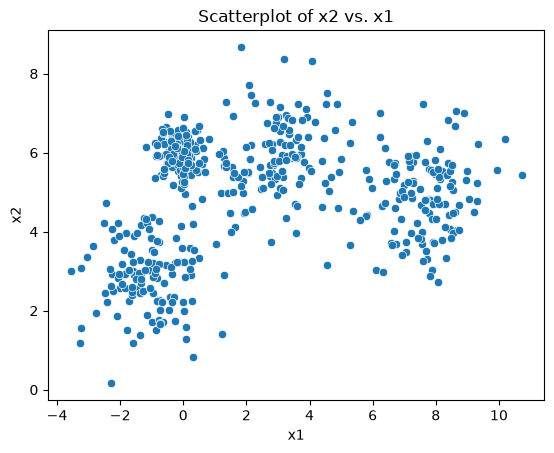

In [20]:
# Show the 500 points on the plot
plt.title('Scatterplot of x2 vs. x1')
sns.scatterplot(df, x=df['x1'], y=df['x2'])
plt.show()

##### 1eii) Density Plot

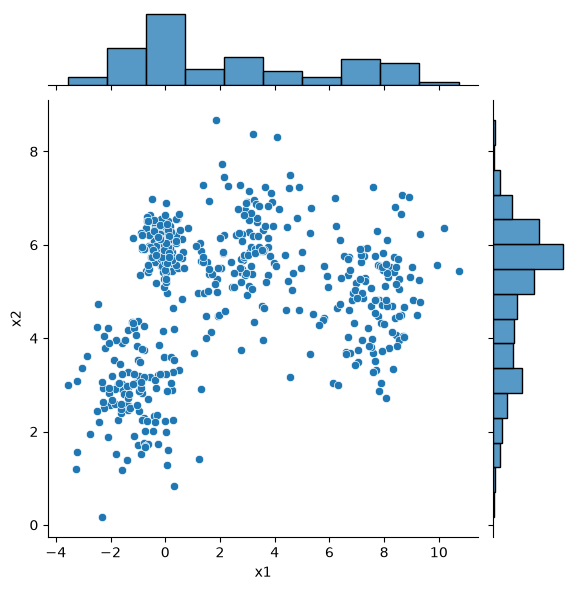

In [25]:
# Show the scatter and density plot
sns.jointplot(df, x=df['x1'], y=df['x2'])

---

### 1f) Discussion

From initial dataset exploration, the dataset is very simple and straightforward with 500 points spanning a neat 2D plane.  There appears to be some potential issues where the `x1` feature involves negative values.  Otherwise, from a strictly visual aspect with respect to clustering algorithms, there appears to be 4 clusters.  One of which is tightly clustered in the top left corner and the other three more diffused and overlapping with neighboring clusters.  In other words, the density of one cluster is high whereas the other 3 have lower densities.  

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 2 - Data Preparation

- [Back to Table of Contents](#table-of-contents)

</div>

### 2a) Scaling

In [48]:
# Scale both 'x1' and 'x2' for consistency in the 2D plane
df_scaled = StandardScaler().fit_transform(df[['x1', 'x2']])

# Send scaled data into a pandas dataframe
df_scaled = pd.DataFrame(df_scaled, columns=['x1', 'x2'], index=df.index)

# Observe descriptive statistics
df_scaled.describe()

,x1,x2
count,5.000000e+02,5.000000e+02
mean,-8.526513e-17,-3.979039e-16
std,1.001002e+00,1.001002e+00
min,-1.673046e+00,-3.173256e+00
25%,-7.791957e-01,-7.422841e-01
50%,-3.505475e-01,3.183255e-01
75%,8.442889e-01,7.041251e-01
max,2.387942e+00,2.520272e+00


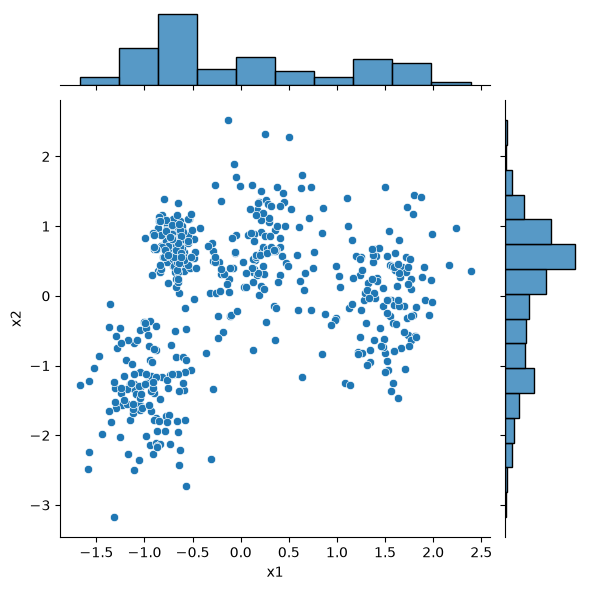

In [49]:
# Re-observe the density and scatterplot of the scaled data
sns.jointplot(df_scaled, x=df_scaled['x1'], y=df_scaled['x2'])

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 3 - Identify Potential Outliers

- [Back to Table of Contents](#table-of-contents)

</div>

### 3a) Create IsolationForest

In [54]:
# Create the IsolationForest model
if_scaled = IsolationForest(n_estimators=1000, 
                            max_samples=0.5,
                            max_features=1.0,
                            random_state=411)

---

### 3b) Establish IsolationForest Anomaly Threshold

In [55]:
# Fit the IsolationForest on the scaled data
if_scaled.fit(df_scaled[['x1', 'x2']])

# Extract anomaly scores
anomaly_scores = if_scaled.decision_function(df_scaled[['x1', 'x2']])

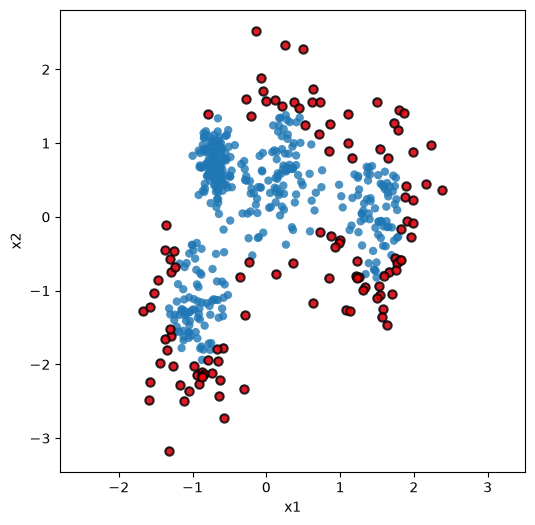

In [74]:
# Visualize what is identified as anomalies initially
fig, ax = plt.subplots(nrows= 1, ncols= 1, figsize= (6, 6))
sns.scatterplot(data= df_scaled, x = 'x1', y = 'x2', 
                alpha = 0.8, edgecolor= 'none', 
                ax= ax, legend= False)
sns.scatterplot(data= df_scaled[anomaly_scores < 0], x = 'x1', y = 'x2', 
                color='red', alpha = 0.8, edgecolors= 'black', linewidth= 1.5, 
                ax= ax, )
plt.axis('equal')
plt.show()

In [91]:
print(f'\033[35mTotal Identified Anomalies: \033[0m{df_scaled[anomaly_scores<0].shape[0]}')

Total Identified Anomalies: 113


---

### 3c) Anomaly Histogram

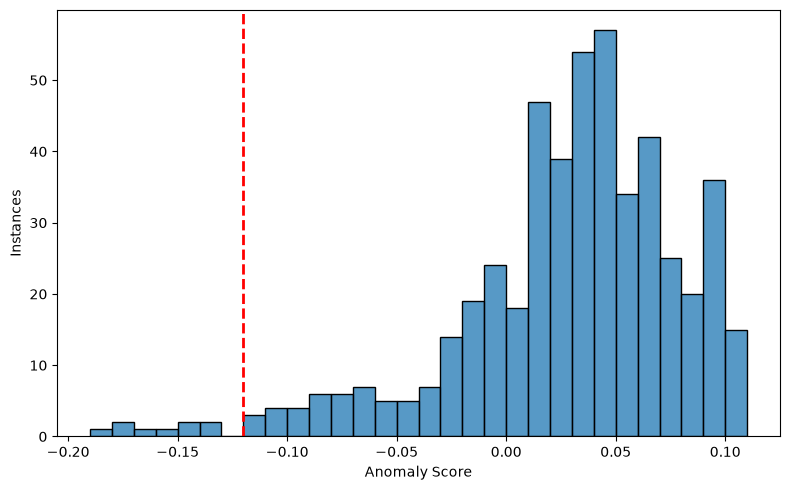

In [75]:
# Update anomaly score threshold
anom_score_min = np.floor(anomaly_scores.min()*100)
anom_score_max= np.ceil(anomaly_scores.max()*100)

bins = np.linspace(start= anom_score_min, stop= anom_score_max, num= int(anom_score_max-anom_score_min+1)) / 100

anom_scores_binned = \
pd.cut(x= anomaly_scores, 
       bins= bins,
      ).value_counts().sort_index(ascending= False).reset_index()

updated_anomaly_threshold = anom_scores_binned.loc[anom_scores_binned['count'].argmin()]['index'].right

fig, ax = plt.subplots(nrows= 1, ncols=1 , figsize= (8, 5))
sns.histplot(x= anomaly_scores, bins= bins, ax= ax)
ax.axvline(x= updated_anomaly_threshold, color= 'r', linestyle= '--', linewidth= 2)
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Instances')
plt.tight_layout()
plt.show()

---

### 3d) Plot Outlier/Non-Outlier

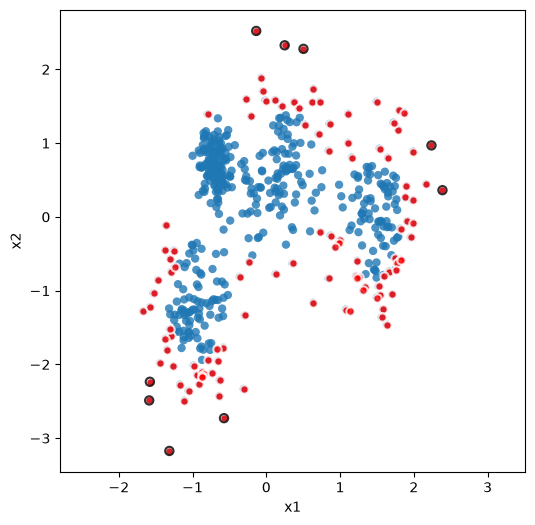

In [76]:
# Manually update the score definition of anomaly and show outliers by updated score
fig, ax = plt.subplots(nrows= 1, ncols= 1, figsize= (6, 6))
sns.scatterplot(data= df_scaled, x = 'x1', y = 'x2', alpha = 0.8, ax= ax, legend= False, edgecolor= 'none')
sns.scatterplot(data= df_scaled[anomaly_scores < 0], x = 'x1', y = 'x2', 
                color='red', alpha = 0.8, linewidth= 1.5, 
                ax= ax, )
sns.scatterplot(data= df_scaled[anomaly_scores <= updated_anomaly_threshold], 
                x = 'x1', 
                y = 'x2', 
                ax= ax, 
                alpha = 0.8, 
                edgecolors= 'black', facecolors= 'none', linewidth= 1.5)
plt.axis('equal')
plt.show()

---

### 3e) Total Outliers

In [82]:
# Get total identified anomalies with updated threshold
print(f'\033[35mTotal Identified Anomalies w/ Updated Score:\033[0m {df_scaled[anomaly_scores <= updated_anomaly_threshold].shape[0]}')

Total Identified Anomalies w/ Updated Score: 9


---

### 3f) Extract Outlier Indicies

In [201]:
# Maintain a list of the identified anomalies by the updated threshold
iso_anomaly_index_list = df_scaled[anomaly_scores <= updated_anomaly_threshold].index.to_list()

# Ensure 9 indicies were saved
print(9 == len(iso_anomaly_index_list))

True


---

### 3g) Discussion

With isolation forest's built-in anomaly score functionality, it identified 113/500 anomalies from the scaled dataset.  By binning the anomaly scores in a linear space and identifying the least frequent bin and taking the supremum of that as the cutoff for anomalies - Alternatively, only data points that exist strictly within the least frequent bin are considered anomalies - the identified anomalies were reduced to 9/500 from the scaled dataset.  To reitterate, there are 9 identified anomalies within the scaled dataset.

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 4 - K-Means Clustering

- [Back to Table of Contents](#table-of-contents)

</div>

### 4a) Identify Optimal Clusters

##### 4ai-4aiii) Elbow Method, Silhouette Score, Davies-Bouldin Score

In [99]:
## Calculate evaluation metrics for values of k

metrics_per_k = np.empty((0, 4))
for k in np.arange(start= 2, stop= 21, step= 1, dtype= int):
    
    kmeans = KMeans(n_clusters= k, random_state= 411).fit(df_scaled)
    gmm = GaussianMixture(n_components= k, random_state= 411).fit(df_scaled)
    
    metrics_per_k = np.vstack([metrics_per_k, 
                               np.array([k, 
                                         kmeans.inertia_, 
                                         silhouette_score(df_scaled, kmeans.labels_),
                                         davies_bouldin_score(df_scaled, kmeans.labels_)
                                        ])
                              ])

## Identify the optimal value of k from silhouette, davies-bouldin, and information criteria
optimal_k_silhouette = metrics_per_k[metrics_per_k[:, 2].argmax(), 0]
optimal_k_daviesbouldin = metrics_per_k[metrics_per_k[:, 3].argmin(), 0]

---

### 4b) Visualize Optimization Methods

Text(0.5, 1.0, 'Minimum Davies-Bouldin $k$=3')

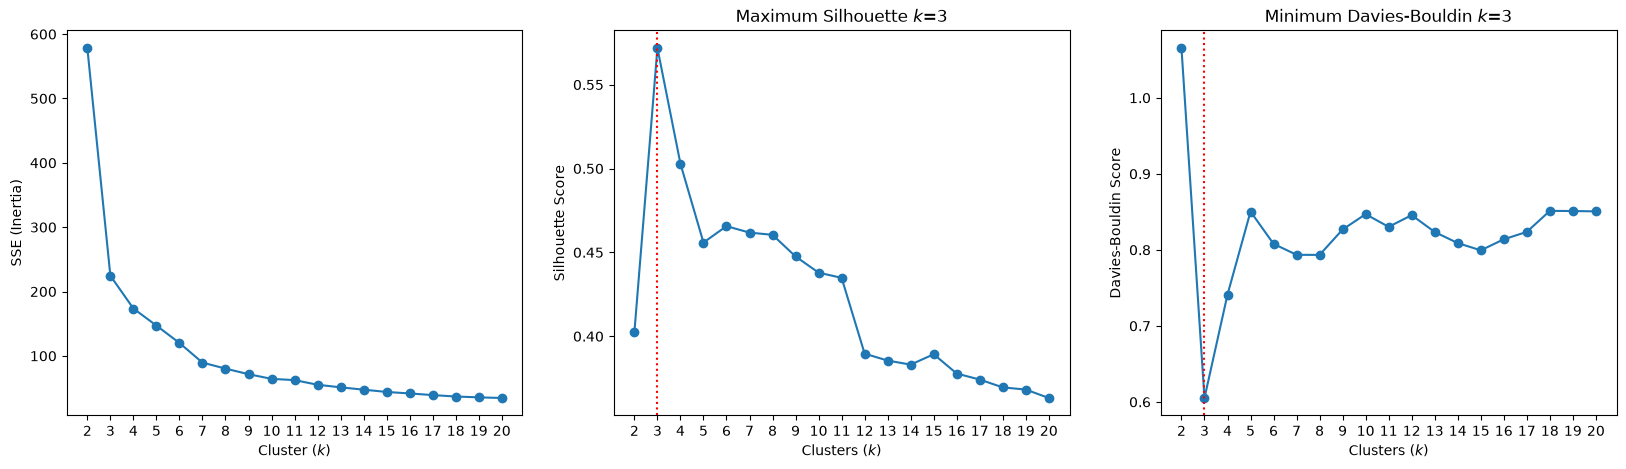

In [100]:
## Plotting
fig, ax = plt.subplots(nrows= 1, ncols= 3, figsize= (20, 5))
ax[0].scatter(x= metrics_per_k[:, 0], y= metrics_per_k[:, 1])
ax[0].plot(metrics_per_k[:, 0], metrics_per_k[:, 1])
ax[0].set_xlabel('Cluster ($k$)')
ax[0].set_ylabel('SSE (Inertia)')
ax[0].set_xticks(ticks= np.arange(2, 21, 1))

ax[1].scatter(x= metrics_per_k[:, 0], y= metrics_per_k[:, 2])
ax[1].plot(metrics_per_k[:, 0], metrics_per_k[:, 2])
ax[1].set_xlabel('Clusters ($k$)')
ax[1].set_ylabel('Silhouette Score')
ax[1].axvline(x= optimal_k_silhouette, color= 'r', linestyle= ':')
ax[1].set_xticks(ticks= np.arange(2, 21, 1))
ax[1].set_title(f'Maximum Silhouette $k$={int(optimal_k_silhouette)}')

ax[2].scatter(x= metrics_per_k[:, 0], y= metrics_per_k[:, 3])
ax[2].plot(metrics_per_k[:, 0], metrics_per_k[:, 3])
ax[2].set_xlabel('Clusters ($k$)')
ax[2].set_ylabel('Davies-Bouldin Score')
ax[2].axvline(x= optimal_k_daviesbouldin, color= 'r', linestyle= ':')
ax[2].set_xticks(ticks= np.arange(2, 21, 1))
ax[2].set_title(f'Minimum Davies-Bouldin $k$={int(optimal_k_daviesbouldin)}')

---

### 4c) Discussion

Implementing 3 methods of determining the optimal amount of clusters for the scaled dataset, the elbow method arguably could be at 3 or 7 clusters, whereas both the silhouette and Davies-Bouldin agree at 3 clusters.  Across all 3 methods, 3 clusters is a mutually agreed upon cluster amount for the scaled dataset and thus will be used for an assumed optimal K-Means algorithm.  Note that earlier from a visual and density based aspect in 1f, it was assumed to be 4 clusters, but through the aforementioned methods, 3 clusters will be implemented for the K-Means algorithm moving forward.

---

### 4d) Train Optimized K-Means

In [ ]:
# Create the optimized K-Means algorithm
kmeans_scaled_optimized = KMeans(n_clusters=3, random_state=411).fit(df_scaled)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 5 - Gaussian Mixture Model

- [Back to Table of Contents](#table-of-contents)

</div>

### 5a) Identify Optimal Clusters

In [105]:
# Use AIC/BIC calculations to determine the optimum cluster amount
bic_aic = np.empty((0, 3))
for k in np.arange(start= 1, stop= 11, step= 1, dtype= int):
    gm = GaussianMixture(n_components= k, random_state= 411).fit(df_scaled)
    bic_aic = np.vstack([bic_aic, np.array([k, 
                                            gm.aic(df_scaled), 
                                            gm.bic(df_scaled)])]) 


opt_bic = bic_aic[np.argmin(bic_aic[:, 2])][0]

---

### 5b) Visualize AIC/BIC

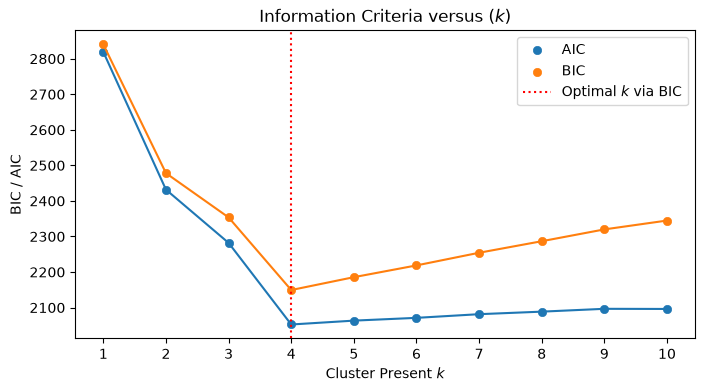

In [107]:
# Visualize 5a's results
fig, ax = plt.subplots(1, 1, figsize= (8, 4))
sns.scatterplot(x= bic_aic[:, 0], y= bic_aic[:, 1], label= 'AIC', edgecolor= None)
sns.lineplot(x= bic_aic[:, 0], y= bic_aic[:, 1])
sns.scatterplot(x= bic_aic[:, 0], y= bic_aic[:, 2], label= 'BIC', edgecolor= None)
sns.lineplot(x= bic_aic[:, 0], y= bic_aic[:, 2])
ax.axvline(x= opt_bic, c= 'red', linestyle= ':', label= 'Optimal $k$ via BIC')

ax.set_xlabel('Cluster Present $k$')
ax.set_ylabel('BIC / AIC')
ax.set_title('Information Criteria versus $(k)$')
ax.set_xticks(ticks= np.linspace(1, 10, 10, dtype= int))
plt.legend()
plt.show()

---

### 5c) Discussion

Using the AIC/BIC calculations with the Gaussian Mixture algorithm to determine the optimal cluster amount for the scaled dataset suggests that 4 clusters is the optimal cluster amount.  Note that this calculation agrees with the visual and density based reasoning from 1f, but does not agree with the 3 clusters K-Means suggested.  As far as the Gaussian Mixture algorithm goes, 4 clusters will be used for this particular algorithm as the optimal cluster amount.

---

### 5d) Train Optimized Gaussian

In [108]:
# Create the optimized Gaussian Mixture algorithm
gm_scaled_optimized = GaussianMixture(n_components=4, random_state=411).fit(df_scaled)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 6 - DBSCAN

- [Back to Table of Contents](#table-of-contents)

</div>

### 6a) Optimize `min_samples`

Note that min_samples is best informed by a subject matter expert, but in our case, we will simply use $2\times f$ to start where $f$ is the amount of columns being used for training (i.e. 2 for this particular dataset).

In [114]:
# Default min_samples is 4 (2x2)
neighborhood_size = 4

---

### 6b) Optimize `eps`

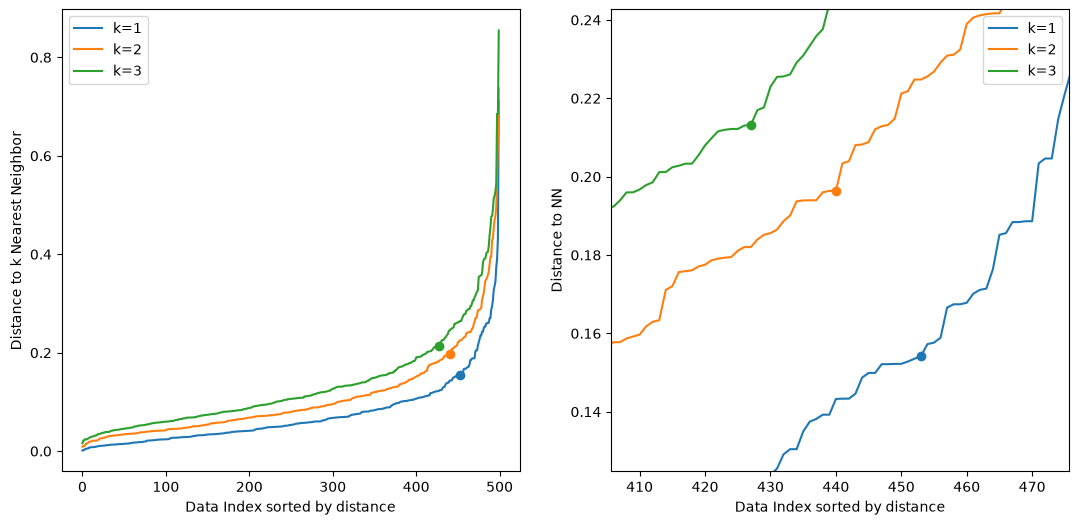

In [145]:
nbrs = NearestNeighbors(n_neighbors= neighborhood_size).fit(df_scaled)
distances, indices = nbrs.kneighbors(df_scaled)

opt_esp_minpts = np.empty((0, 3))
fig, (ax0, ax1) = plt.subplots(nrows= 1, ncols= 2, figsize= (13, 6))
for k in np.arange(1, neighborhood_size):
    
    ## Calculate distance to kth nearest neighbor (knn)
    knn_distances = np.sort(distances[:, k])

    ## Scale knn to [0, 1]
    scaled_knn_dists = (knn_distances - knn_distances.min()) / (knn_distances.max() - knn_distances.min())

    ## Scale indices to [0, 1]
    scaled_idx = np.linspace(start= 0, stop= 1, num= int(scaled_knn_dists.shape[0]))

    knn_coords = np.concatenate([scaled_idx, scaled_knn_dists]).reshape(2, -1).T
    line_coords = np.concatenate([scaled_idx, scaled_idx]).reshape(2, -1).T
    
    line_to_knn_dists = cdist(XA = knn_coords, XB= line_coords)
    idx_opt = line_to_knn_dists.min(axis= 1).argmax()
    
    opt_esp_minpts = np.vstack([opt_esp_minpts, np.array([k, idx_opt, knn_distances[idx_opt]])]) 
    
    ax0.plot(knn_distances, label= f'k={k}')
    ax0.scatter(x= idx_opt, y= knn_distances[idx_opt])
    
    ax1.plot(knn_distances, label= f'k={k}')
    ax1.scatter(x= idx_opt, y= knn_distances[idx_opt])
    
    
eps_delta = opt_esp_minpts[:, 2].max() - opt_esp_minpts[:, 2].min()

ax0.legend()
ax0.set_xlabel('Data Index sorted by distance')
ax0.set_ylabel('Distance to k Nearest Neighbor')

ax1.set_xlim([opt_esp_minpts[:, 1].min()*0.95, 
              opt_esp_minpts[:, 1].max()*1.05])

ax1.set_ylim([opt_esp_minpts[:, 2].min() - 0.5*eps_delta,
              opt_esp_minpts[:, 2].max() + 0.5*eps_delta])    
ax1.legend()
ax1.set_xlabel('Data Index sorted by distance')
ax1.set_ylabel('Distance to NN')

plt.show()

In [146]:
k = neighborhood_size - 1
## Calculate distance to kth nearest neighbor (knn)
knn_distances = np.sort(distances[:, k])
## Scale knn to [0, 1]
scaled_knn_dists = (knn_distances - knn_distances.min()) / (knn_distances.max() - knn_distances.min())
## Scale indices to [0, 1]
scaled_idx = np.linspace(start= 0, stop= 1, num= int(scaled_knn_dists.shape[0]))
## Construct the two curves
knn_coords = np.concatenate([scaled_idx, scaled_knn_dists]).reshape(2, -1).T
line_coords = np.concatenate([scaled_idx, scaled_idx]).reshape(2, -1).T
## Calculate distances between two curves
line_to_knn_dists = cdist(XA = knn_coords, XB= line_coords)
## Identify the largest smallest distance
idx_opt = line_to_knn_dists.min(axis= 1).argmax()
## Extract the optimum epsilon value
opt_eps = knn_distances[idx_opt]

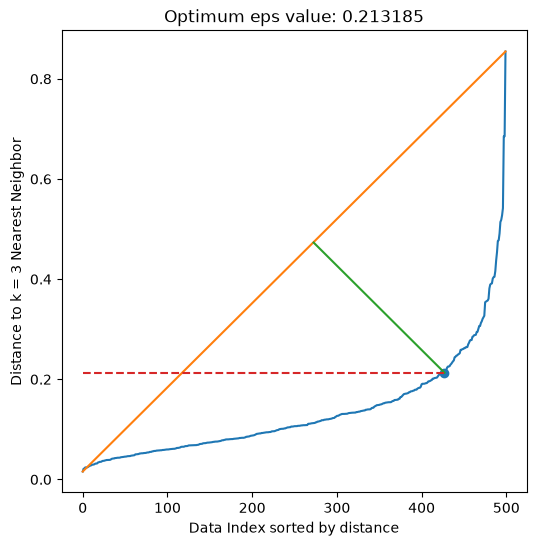

In [147]:
perp_line = np.array([
    [idx_opt, opt_eps],
    [line_coords[line_to_knn_dists[idx_opt].argmin()][0] * knn_distances.shape[0], 
     line_coords[line_to_knn_dists[idx_opt].argmin()][1] * (knn_distances.max() - knn_distances.min()) + knn_distances.min()
    ]
])

plt.figure(figsize= (6, 6))
plt.plot(knn_distances, label= f'Distance to k={k} Nearest Neighbor')
plt.plot(np.linspace(start= knn_distances.min(), stop= knn_distances.max(), num= int(knn_distances.shape[0])))
plt.scatter(x= idx_opt, y= opt_eps)
plt.plot(perp_line[:, 0], perp_line[:, 1])
plt.plot([0, idx_opt], [opt_eps, opt_eps], linestyle= '--')
plt.ylabel(f'Distance to k = {int(k)} Nearest Neighbor')
plt.xlabel('Data Index sorted by distance')
plt.title(f'Optimum eps value: {np.round(opt_eps, 6)}')
#plt.legend()
plt.show()

---

### 6c) Train Optimized DBSCAN

In [198]:
# Create the optimized DBSCAN algorithm
dbscan_scaled_optimized = DBSCAN(min_samples=neighborhood_size, eps=opt_eps).fit(df_scaled)

---

### 6d) Total Outliers

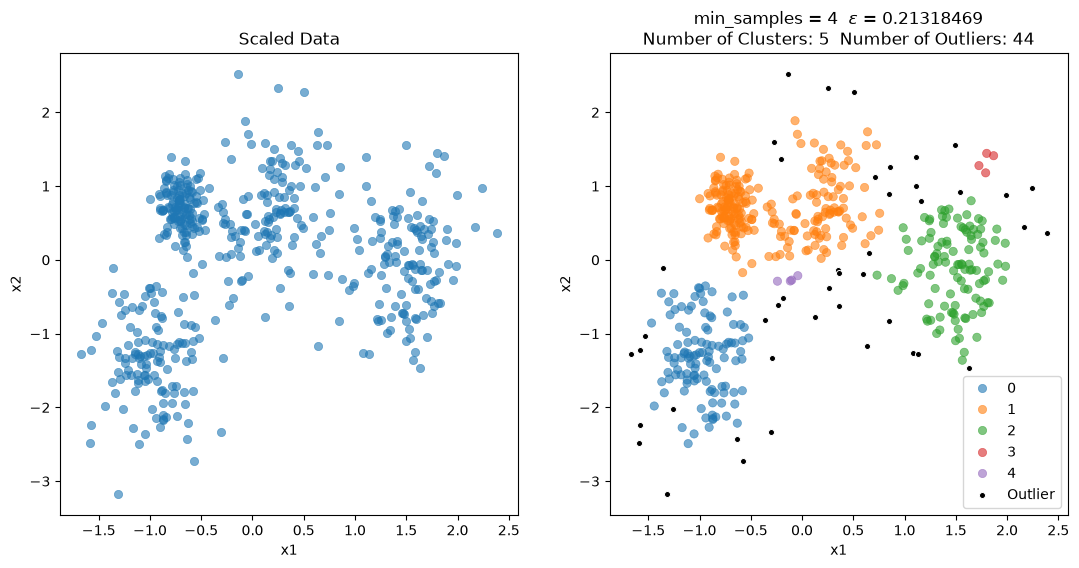

In [199]:
# Observe outliers of optimized DBSCAN
labels_db = dbscan_scaled_optimized.labels_
clstr, cnts = np.unique(dbscan_scaled_optimized.labels_, return_counts= True)

fig, ax = plt.subplots(nrows= 1, ncols= 2, figsize= (13, 6))
sns.scatterplot(x= df_scaled.x1, y= df_scaled.x2, alpha= 0.6, ax= ax[0], edgecolor= None)
ax[0].set_title('Scaled Data')

sns.scatterplot(data= df_scaled[dbscan_scaled_optimized.labels_ > -1], x= 'x1', y= 'x2', 
                hue= labels_db[dbscan_scaled_optimized.labels_ > -1], 
                alpha= 0.6, palette= 'tab10', ax= ax[1], edgecolor= None)
sns.scatterplot(data= df_scaled[dbscan_scaled_optimized.labels_ == -1], x= 'x1', y= 'x2', 
                color= 'black', marker= '.', s= 75, label= 'Outlier',
                ax= ax[1])
ax[1].set_title(f'min_samples = {int(opt_esp_minpts[-1, 0] + 1)}  $\\epsilon$ = {np.round(opt_esp_minpts[-1, 2], 8)}\nNumber of Clusters: {(clstr != -1).sum()}  Number of Outliers: {cnts[clstr == -1][0]}')
plt.show()

---

### 6e) Visualize Clusters and Outliers

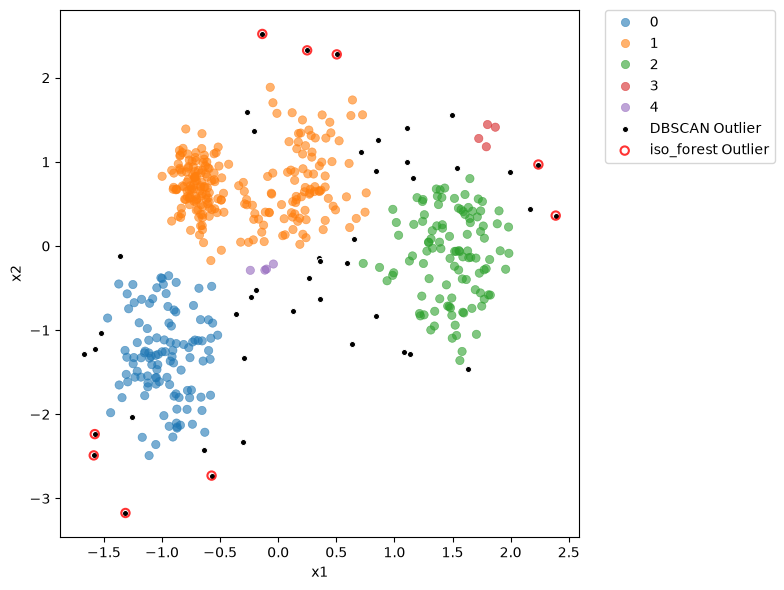

In [200]:
# Compare the DBSCAN and Isolation Forest outliers
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(data= df_scaled[dbscan_scaled_optimized.labels_ > -1], x= 'x1', y= 'x2', 
                hue= labels_db[dbscan_scaled_optimized.labels_ > -1], 
                alpha= 0.6, palette= 'tab10', edgecolor= None, ax=ax)
sns.scatterplot(data= df_scaled[dbscan_scaled_optimized.labels_ == -1], x= 'x1', y= 'x2', 
                color= 'black', marker= '.', s= 75, label= 'DBSCAN Outlier', ax=ax)
sns.scatterplot(data= df_scaled[anomaly_scores <= updated_anomaly_threshold], 
                x = 'x1', y = 'x2', alpha = 0.8, edgecolors= 'red', 
                facecolors='none', linewidth= 1.5, label= 'iso_forest Outlier', ax=ax)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

---

### 6f) Discussion

**On The Identified Clusters**

Though the 3 large clusters make visual sense, notice the 2 additional and very small clusters near the middle of the visualization and the cluster above the rightmost large cluster.  These were considered as their own clusters apart from the larger 3 because `eps` is just large enough that their distance to neighboring points fell outside of what is considered to be within a cluster and thus got pushed into their own cluster.  To fix this could be to slowly increase `eps` until these two small clusters are ingested into the larger clusters, however, without much information of the underlying meaning of this dataset, it's best to just leave the `eps` as is for now.

**Isolation Forest vs. DBSCAN Anomaly Detection**

Between the Isolation Forest and DBSCAN, note that the methodology of determining outliers are different.  The updated binning method of the Isolation Forest identified the lowest frequency bin and cut it at the supremum to then identify this bin as the outliers of the scaled dataset.  DBSCAN utilized a similar notion of the "elbow method" to then optimize the `eps` hyperparameter - or epsilon - that generally will cluster very tight groups of points as `eps` approaches 0 and will cluster more diffused or noisy points as `eps` becomes larger.  6b attempted to determine the most optimal `eps` value by iterating through neighbors and recording distances from other points which was later used in a visualization where we wanted to be able to group the most amount of points at the least distance, thus the "elbow method" similarity.  In other words, Isolation Forest assigned anomaly scores to all points and then we only considered the least frequent bin as true anomalies whereas DBSCAN will consider any point that falls outside an expected density as a true anomaly which explains the large contrast in anomalies found between the two as 9 vs. 44.  Do note that prior to binning the Isolation Forest, the anomalies detected in the Isolation Forest was 113 vs. 44 which is a fairly substantial amount of the dataset.

**On Real/Fake Anomalies**

In the case of whether or not the identified anomalies are actually anomalies, it should be noted that the definition of an anomaly can be very subjective.  The best way of determining real vs. fake anomalies would arguably be best handled by a subject matter expert and having actual understanding of what the data represents.  Otherwise, it can be left to statistics and things like Tukey's method to determine data points that fall outside a specified range as anomalous.  As far as what was done through the isolation forest and DBSCAN, we defined what we consider to be anomalies, but again, this is very subjective and doesn't offer much in whether or not the identified anomalies are real or not.  Arguably for the DBSCAN's 44 identified anomalies, one could say that ~10% of the dataset being anomalous is too large of a number to consider as anomalous data - Though again, depending on the situation, 10% may be acceptable - so for those who may think it too large, one could simply increase `eps` slowly until a desired anomaly threshold is met.  However, as mentioned earlier as to the subjectivity of the term anomaly and the fact that the dataset has no underlying meaning to it besides being used as a good clustering dataset for strong visual aid in learning, the `eps` will not be altered.

---

### 6g) Make Copy and Remove Outliers

In [206]:
# Get the DBSCAN anomaly indicies
dbscan_anomaly_index_list = df_scaled[dbscan_scaled_optimized.labels_ == -1].index.to_list()

# Ensure 44 indicies were extracted
print(44 == len(dbscan_anomaly_index_list))

True


In [209]:
# Make a copy of df_scaled with the DBSCAN anomaly indices dropped
df_scaled_dbscan_no_anomaly = df_scaled.drop(index=dbscan_anomaly_index_list).copy()

# Ensure that 456 entries remain in the copied dataset
print(456 == df_scaled_dbscan_no_anomaly.shape[0])

True


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 7 - Model Evaluation and Selection

- [Back to Table of Contents](#table-of-contents)

</div>

### 7a) Visualize 3 Model Clustering

---

### 7b) Discussion of Clustering

---

### 7c) Silhouette Scores and Davies-Bouldin Scores

---

### 7d) Discussion of Scores